File: AmpHGT_PeptideMTR_lg_results.csv
AUROC: 0.9291648917373814, AUPRC: 0.9245562522335555
F1: 0.8776900954358607, MCC: 0.7354442106763468, Accuracy: 0.8675213675213675
File: AmpHGT_PeptideMLM_lg_results.csv
AUROC: 0.9530456576355036, AUPRC: 0.938496577857909
F1: 0.9133611641214759, MCC: 0.8127598100048554, Accuracy: 0.9032634032634033
File: AmpHGT_PeptideMLM-MTR_lg_results.csv
AUROC: 0.9431398882278622, AUPRC: 0.9274123824394631
F1: 0.8950427300733822, MCC: 0.7714657138326743, Accuracy: 0.8807303807303807


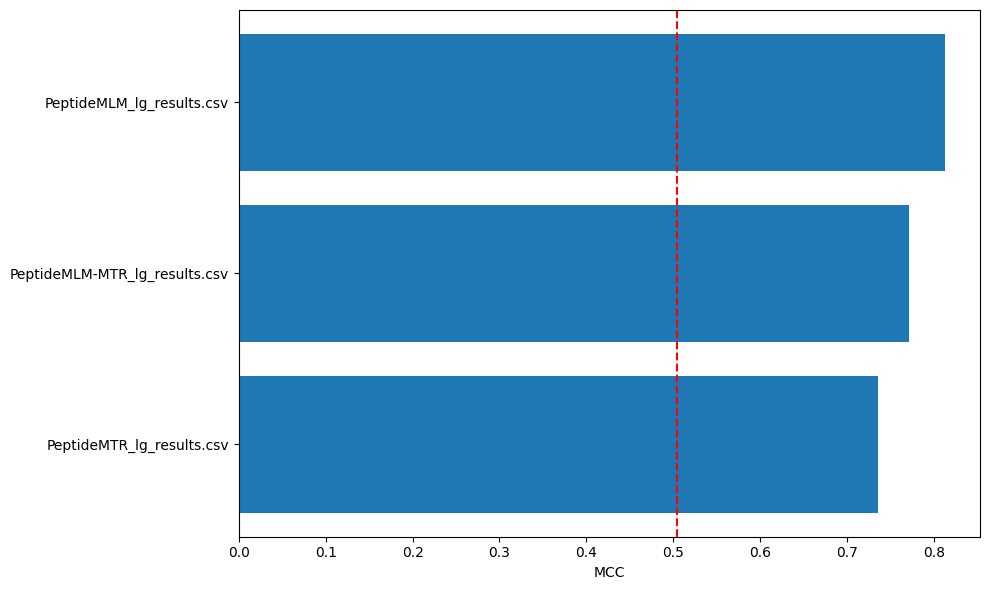

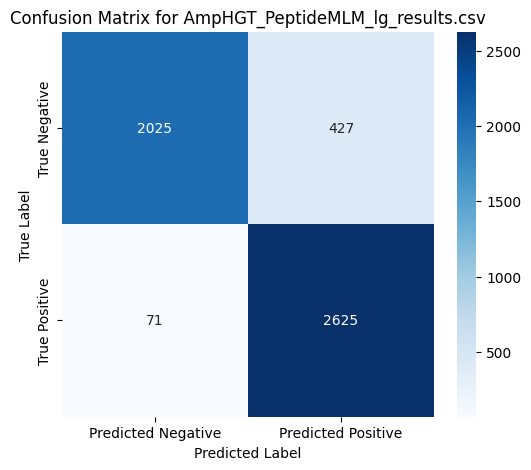

In [16]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import matthews_corrcoef, accuracy_score
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
# load files from ../results
import os
import pandas as pd

directory = "../results"

aucs = []
prcs = []
mccs = []

files = [f for f in os.listdir(directory) if "AmpHGT" in f and "lg" in f and f.endswith(".csv")]
for file in files:
    df = pd.read_csv(os.path.join(directory, file))
    
    # calculate auroc and auprc for each dataframe
    y_true = df['true_label']
    y_scores = df['predicted_label']
    auroc = roc_auc_score(y_true, y_scores)
    auprc = average_precision_score(y_true, y_scores)

    # do mcc and accuracy at best threshold
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores[:-1])]
    y_pred = (y_scores >= best_threshold).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    print(f"File: {file}\nAUROC: {auroc}, AUPRC: {auprc}\nF1: {f1_scores.max()}, MCC: {mcc}, Accuracy: {accuracy}")

    aucs.append(auroc)
    prcs.append(auprc)
    mccs.append(mcc)

average_benchmark = (0.5042 + 0.502 + 0.4911 + 0.524 + 0.5023) / 5

# make barplot of mcc across files
plt.figure(figsize=(10, 6))
# sort by mcc
mccs, files = zip(*sorted(zip(mccs, files)))

# add the benchmark to the plot
plt.axvline(x=average_benchmark, color='r', linestyle='--', label='Benchmark')
plt.barh(range(len(mccs)), mccs, tick_label=[f.replace('AmpHGT_', '') for f in files])
plt.xlabel('MCC')
plt.tight_layout()
plt.show()

# build confusion matrix for the best file processed
best_file = files[np.argmax(mccs)]
df = pd.read_csv(os.path.join(directory, best_file))
y_true = df['true_label']
y_scores = df['predicted_label']
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]
y_pred = (y_scores >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {best_file}')
plt.show()

File: CellPPD_PeptideMTR_lg_results.csv
AUROC: 0.9701973333333335, AUPRC: 0.976859286327587
F1: 0.9251887389988643, MCC: 0.8560748313627049, Accuracy: 0.9273333333333333
File: CellPPD_PeptideMLM_lg_results.csv
AUROC: 0.9726488888888889, AUPRC: 0.9777234822808069
F1: 0.9337792592141028, MCC: 0.8680192895318757, Accuracy: 0.934
File: CellPPD_PeptideMLM-MTR_lg_results.csv
AUROC: 0.9725084444444445, AUPRC: 0.9785942349028387
F1: 0.93622794615488, MCC: 0.8751927183435732, Accuracy: 0.9373333333333334


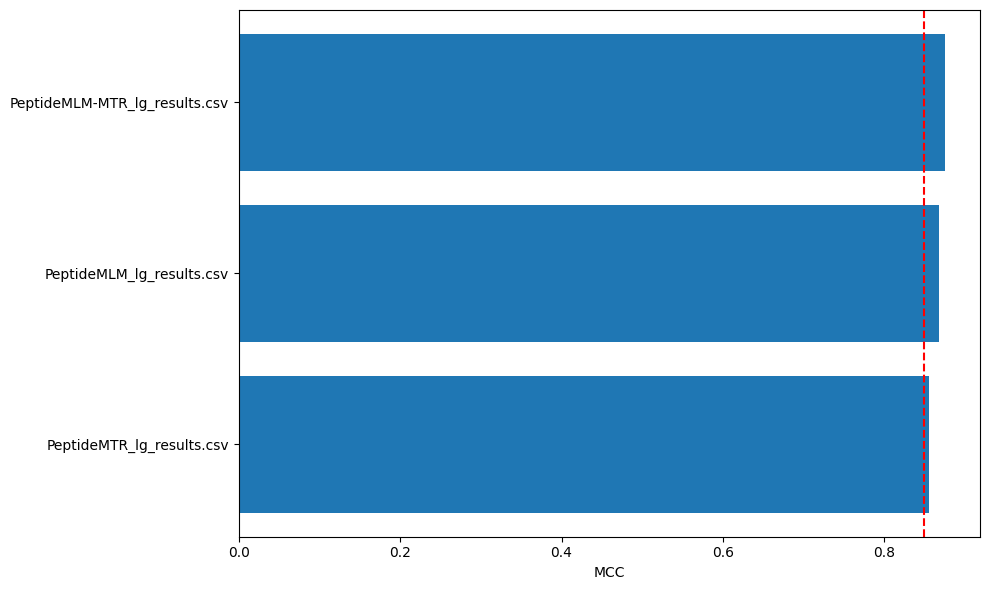

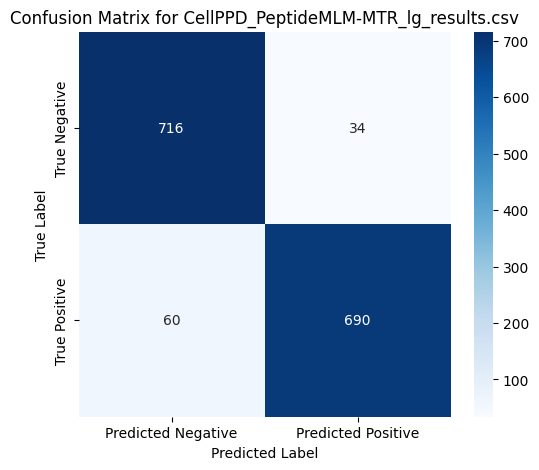

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import matthews_corrcoef, accuracy_score
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
# load files from ../results
import os
import pandas as pd

directory = "../results"


aucs = []
prcs = []
mccs = []

files = [f for f in os.listdir(directory) if "CellPPD" in f and "lg" in f and f.endswith(".csv")]
for file in files:
    df = pd.read_csv(os.path.join(directory, file))

    # calculate auroc and auprc for each dataframe
    y_true = df['true_label']
    y_scores = df['predicted_label']
    auroc = roc_auc_score(y_true, y_scores)
    auprc = average_precision_score(y_true, y_scores)

    # do mcc and accuracy at best threshold
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores[:-1])]
    y_pred = (y_scores >= best_threshold).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    print(f"File: {file}\nAUROC: {auroc}, AUPRC: {auprc}\nF1: {f1_scores.max()}, MCC: {mcc}, Accuracy: {accuracy}")
    aucs.append(auroc)
    prcs.append(auprc)
    mccs.append(mcc)

# make barplot of mcc across files
plt.figure(figsize=(10, 6))
# sort by mcc
mccs, files = zip(*sorted(zip(mccs, files)))
# add the benchmark to the plot
plt.axvline(x=0.85, color='r', linestyle='--', label='Benchmark')
plt.barh(range(len(mccs)), mccs, tick_label=[f.replace('CellPPD_', '') for f in files])
plt.xlabel('MCC')
plt.tight_layout()
plt.show()

# build confusion matrix for the best file processed
best_file = files[np.argmax(mccs)]
df = pd.read_csv(os.path.join(directory, best_file))
y_true = df['true_label']
y_scores = df['predicted_label']
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]
y_pred = (y_scores >= best_threshold).astype(int) 

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {best_file}')
plt.show()

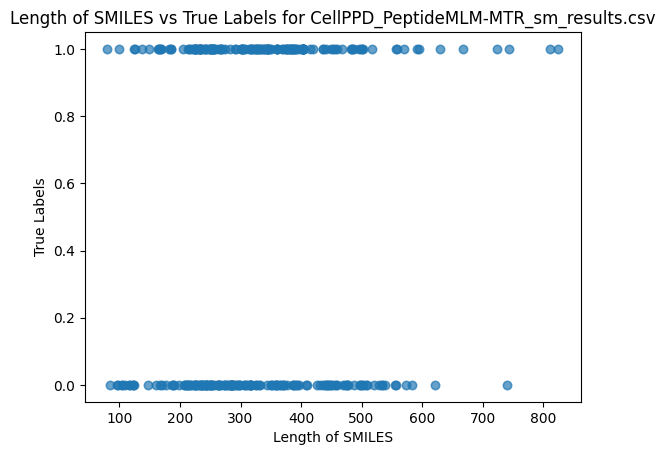

In [15]:

files = os.listdir("../results")

for file in files:
    if "CellPPD" in file and file.endswith(".csv"):
        df = pd.read_csv(os.path.join("../results", file))
        # plot len of 'smiles' vs true_label
        y_true = df['true_label']
        length = df['smiles'].apply(len)
        plt.figure()
        plt.scatter(length, y_true, alpha=0.2)
        plt.xlabel('Length of SMILES')
        plt.ylabel('True Labels')
        plt.title(f'Length of SMILES vs True Labels for {file}')
        plt.show()
        break

File: MHC_PeptideMTR_lg_results.csv
R2: 0.5235504514579108, RMSE: 0.514073112753367
File: MHC_PeptideMLM_lg_results.csv
R2: 0.4460845066273188, RMSE: 0.5976562738945619
File: MHC_PeptideMLM-MTR_lg_results.csv
R2: 0.6589195343424158, RMSE: 0.36801440407802744


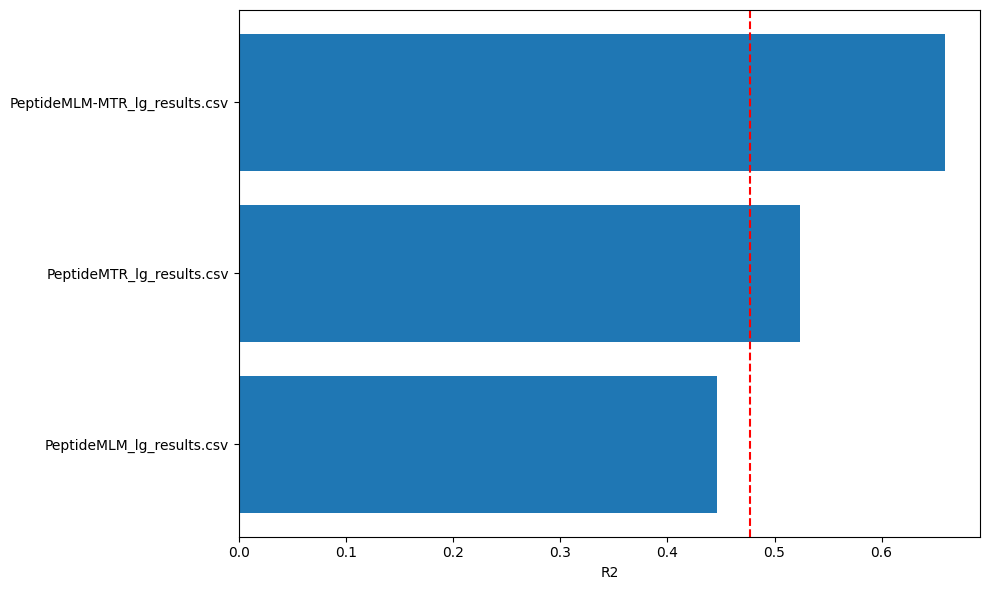

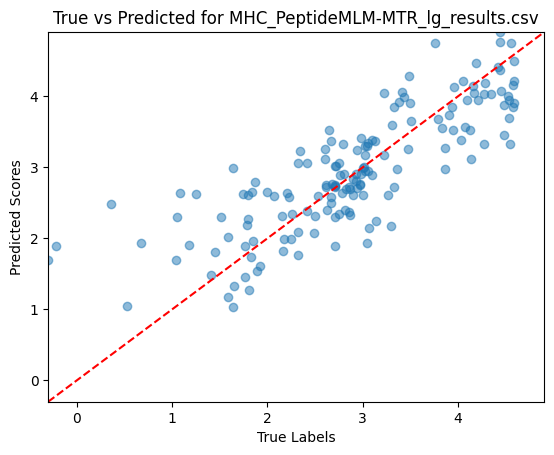

In [21]:
# do it now with MHC

from sklearn.metrics import mean_squared_error, r2_score

directory = "../results2"

r2s = []
rmses = []

files = [f for f in os.listdir(directory) if "MHC" in f and "lg" in f and f.endswith(".csv")]
for file in files:
    df = pd.read_csv(os.path.join(directory, file))

    # calculate auroc and auprc for each dataframe
    y_true = df['true_label']
    # unscale from log10
    y_scores = df['predicted_label']
    # calculate r2 and rmse
    r2 = r2_score(y_true, y_scores)
    rmse = mean_squared_error(y_true, y_scores)
    print(f"File: {file}\nR2: {r2}, RMSE: {rmse}")
    r2s.append(r2)
    rmses.append(rmse)


# plot all r2 in barplot
plt.figure(figsize=(10, 6))
# sort by r2
r2s, files = zip(*sorted(zip(r2s, files)))
plt.barh(range(len(r2s)), r2s, tick_label=[f.replace('MHC_', '') for f in files])
# add the benchmark to the plot
plt.axvline(x=0.477, color='r', linestyle='--', label='Benchmark')
plt.xlabel('R2')
plt.tight_layout()
plt.show()

# build scatter plot for the best file processed
best_file = files[np.argmax(r2s)]
df = pd.read_csv(os.path.join("../results2", best_file))
y_true = df['true_label']
y_scores = df['predicted_label']
plt.figure()
plt.scatter(y_true, y_scores, alpha=0.5)
plt.xlabel('True Labels')
plt.ylabel('Predicted Scores')
plt.title(f'True vs Predicted for {best_file}')
# set min and max to be the same
min_val = min(y_true.min(), y_scores.min())
max_val = max(y_true.max(), y_scores.max())
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
# plot y=x line
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()


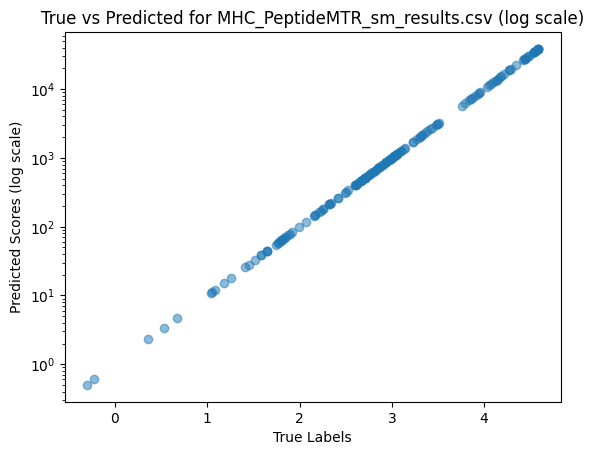

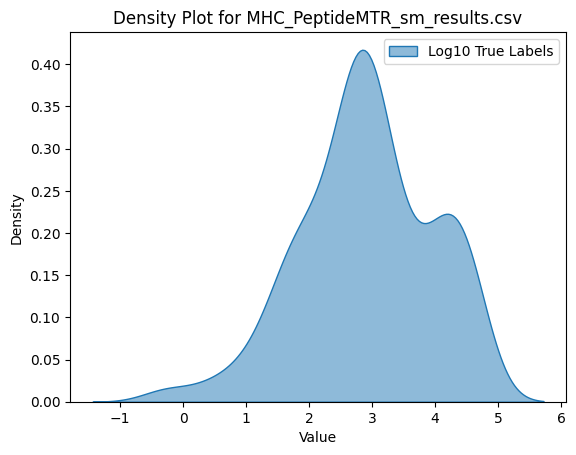

In [10]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# plot true vs true with log transformed on y axis
files = os.listdir("../results")
for file in files:
    if "MHC" in file and file.endswith(".csv"):
        df = pd.read_csv(os.path.join("../results", file))
        y_true = df['true_label']
        y_true_log = df['true_label'].apply(lambda x: np.log10(x + 1e-8))

        import matplotlib.pyplot as plt
        plt.figure()
        plt.scatter(y_true_log, y_true, alpha=0.5)
        plt.yscale('log')
        plt.xlabel('True Labels')
        plt.ylabel('Predicted Scores (log scale)')
        plt.title(f'True vs Predicted for {file} (log scale)')
        plt.show()

        # plot density plot of y_true vs y_true_log
        import seaborn as sns
        plt.figure()
        # sns.kdeplot(y_true, label='True Labels', fill=True, alpha=0.5)
        sns.kdeplot(y_true_log, label='Log10 True Labels', fill=True, alpha=0.5)
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title(f'Density Plot for {file}')
        plt.legend()
        plt.show()
        break
        

In [52]:
# load ../data/MHC_train_original.csv and convert Quantitative Measurement to log scale and resave column 'label' as MHC_train.csv

import pandas as pd
df = pd.read_csv("../data/MHC_train_original.csv")
df['label'] = df['Quantitative Measurement'].apply(lambda x: np.log10(x + 1e-8))
df.to_csv("../data/MHC_train.csv", index=False)

File: THPep_PeptideMTR_lg_results.csv
AUROC: 0.9343113583875707, AUPRC: 0.8581498215171195
F1: 0.7765957397012223, MCC: 0.6803158055724269, Accuracy: 0.8620689655172413
File: THPep_PeptideMLM_lg_results.csv
AUROC: 0.932264329204283, AUPRC: 0.8089197011239275
F1: 0.8118279520036998, MCC: 0.7316189605763215, Accuracy: 0.8850574712643678
File: THPep_PeptideMLM-MTR_lg_results.csv
AUROC: 0.9394945412555112, AUPRC: 0.8628299623499016
F1: 0.78802992026169, MCC: 0.6977953195657794, Accuracy: 0.8604269293924466


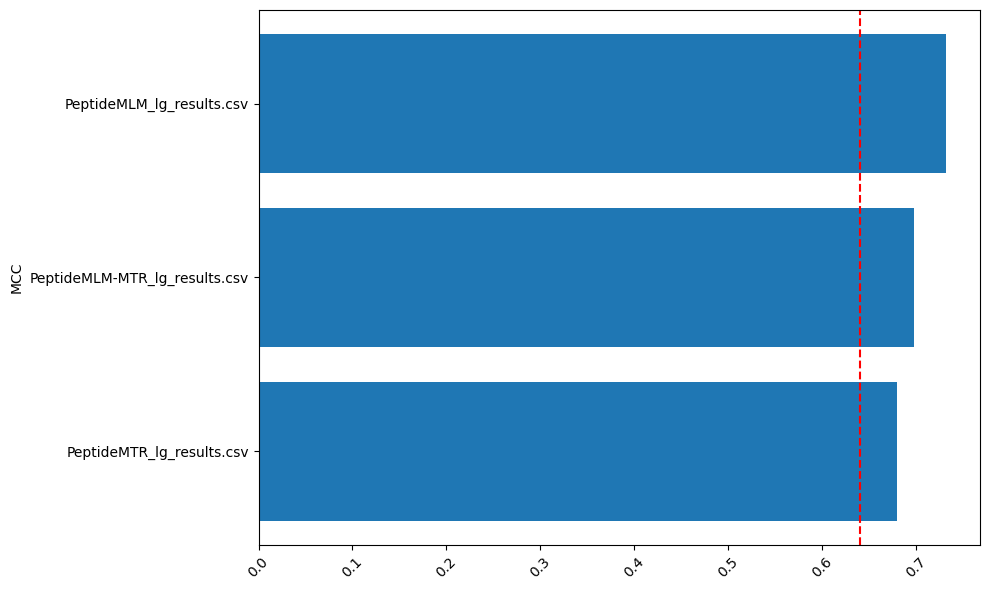

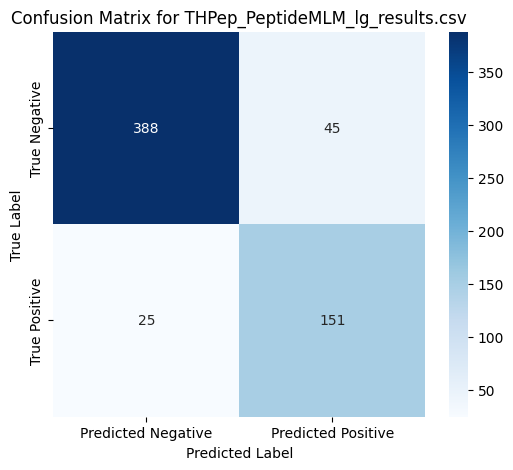

In [19]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import matthews_corrcoef, accuracy_score
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
# load files from ../results
import os
import pandas as pd

files = [f for f in os.listdir("../results") if "THPep" in f and "lg" in f and f.endswith(".csv")]

aucs = []
prcs = []
mccs = []

for file in files:
    df = pd.read_csv(os.path.join("../results", file))

    # calculate auroc and auprc for each dataframe
    y_true = df['true_label']
    y_scores = df['predicted_label']
    auroc = roc_auc_score(y_true, y_scores)
    auprc = average_precision_score(y_true, y_scores)

    # do mcc and accuracy at best threshold
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores[:-1])]
    y_pred = (y_scores >= best_threshold).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    print(f"File: {file}\nAUROC: {auroc}, AUPRC: {auprc}\nF1: {f1_scores.max()}, MCC: {mcc}, Accuracy: {accuracy}")

    aucs.append(auroc)
    prcs.append(auprc)
    mccs.append(mcc)


# make barplot of mcc across files
plt.figure(figsize=(10, 6))
# sort by mcc
mccs, files = zip(*sorted(zip(mccs, files)))
plt.barh(range(len(mccs)), mccs, tick_label=[f.replace('THPep_', '') for f in files])
# add the benchmark to the plot
benchmark_score = (0.64)

plt.axvline(x=benchmark_score, color='r', linestyle='--', label='Benchmark')
plt.ylabel('MCC')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# build confusion matrix for the best file processed
best_file = files[np.argmax(mccs)]
df = pd.read_csv(os.path.join("../results", best_file))
y_true = df['true_label']
y_scores = df['predicted_label']
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]
y_pred = (y_scores >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {best_file}')
plt.show()

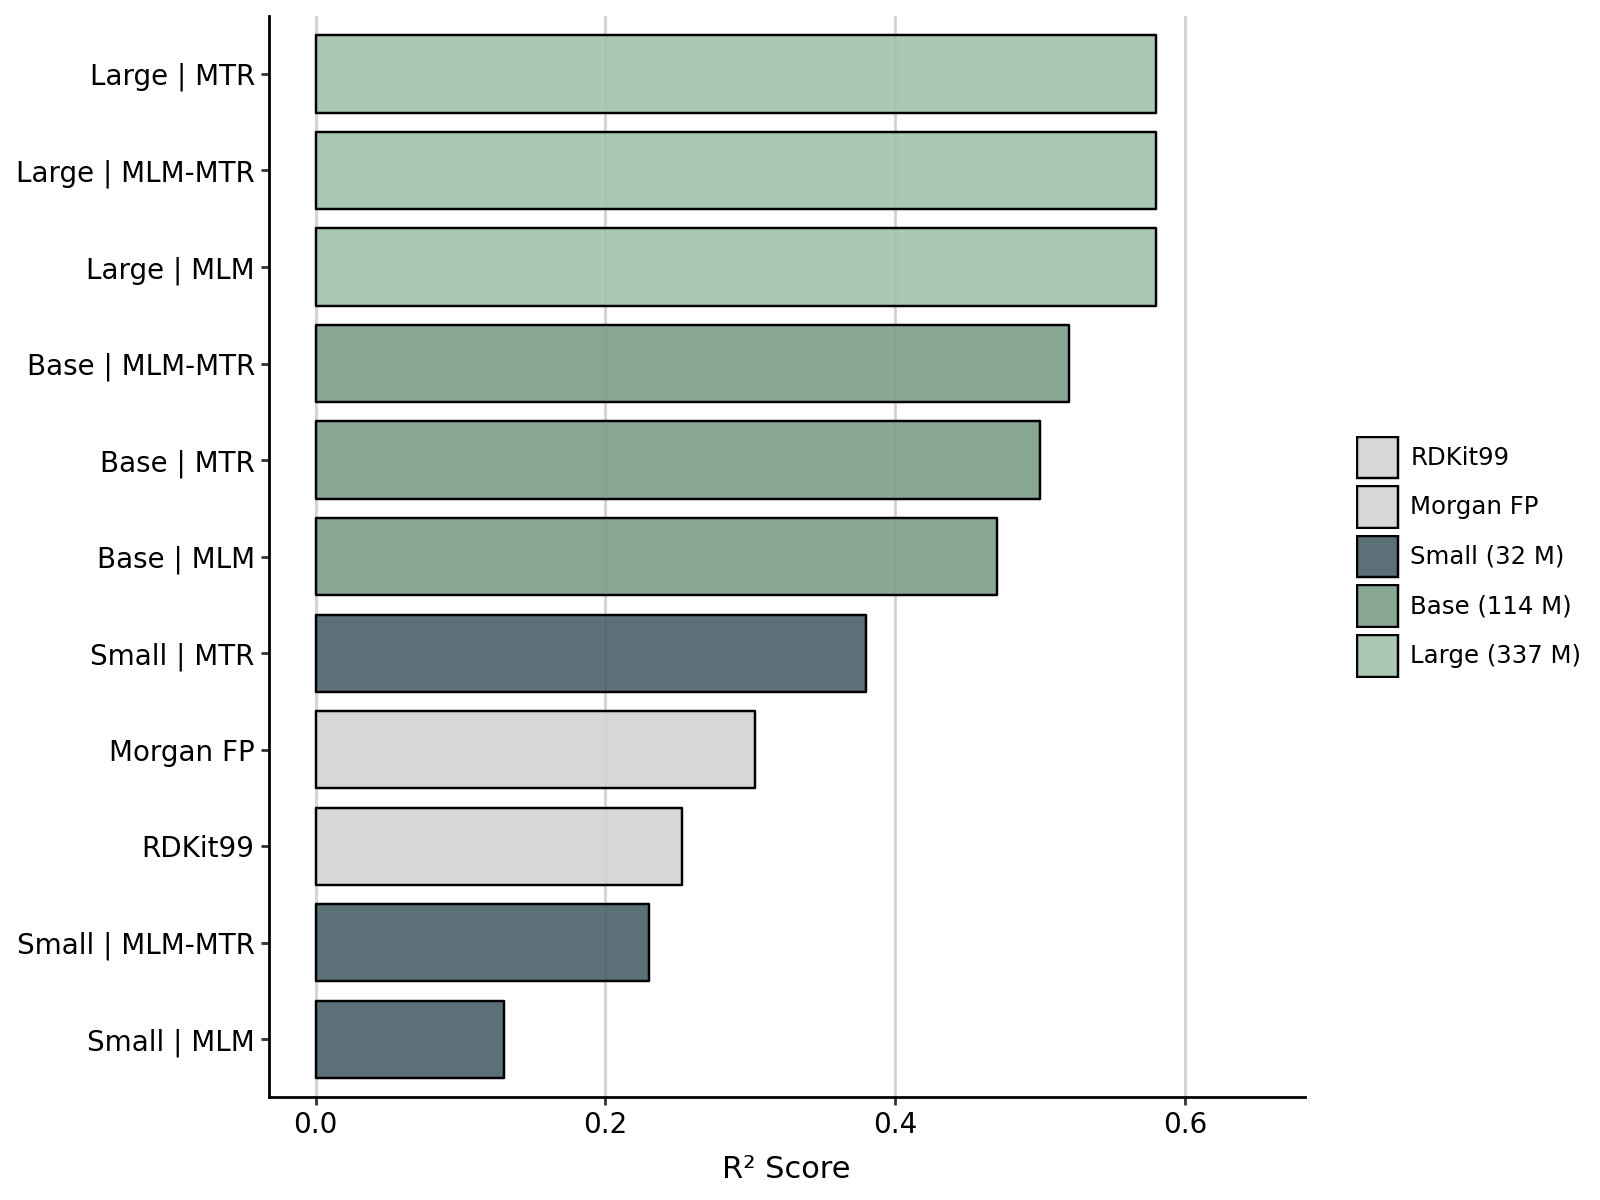

In [ ]:
import pandas as pd
import plotnine as p9

# ---- Data ----
data = [
    # [32, "Kmer", "*", "*", "*", -0.08, 0.80, 0.64, 0.67],
    [32, "Kmer", "Span", "Yes", "No", 0.13, 0.72, 0.68, 0.69],
    [32, "Kmer", "Span", "Yes", "Yes", 0.23, 0.68, 0.70, 0.74],
    # [32, "Kmer", "Random", "Yes", "Yes", 0.24, 0.68, 0.70, 0.74],
    # [32, "Atom", "Random", "Yes", "Yes", 0.25, 0.67, 0.71, 0.74],
    [32, "Kmer", "None", "No", "Yes", 0.38, 0.61, 0.76, 0.73],
    # [114, "Kmer", "Random", "Yes", "Yes", 0.39, 0.59, 0.79, 0.77],
    [114, "Kmer", "Span", "Yes", "No", 0.47, 0.56, 0.80, 0.77],
    [114, "Kmer", "None", "No", "Yes", 0.50, 0.55, 0.80, 0.78],
    [114, "Kmer", "Span", "Yes", "Yes", 0.52, 0.54, 0.81, 0.78],
    # [337, "Kmer", "Random", "Yes", "Yes", 0.57, 0.51, 0.83, 0.81],
    [337, "Kmer", "Span", "Yes", "No", 0.58, 0.50, 0.83, 0.81],
    [337, "Kmer", "Span", "Yes", "Yes", 0.58, 0.50, 0.83, 0.81],
    [337, "Kmer", "None", "No", "Yes", 0.58, 0.50, 0.83, 0.81],
    [0, "Morgan FP", "N/A", "N/A", "N/A", 0.303, None, None, None],
    [1, "RDKit99", "N/A", "N/A", "N/A", 0.253, None, None, None],
]

df = pd.DataFrame(
    data, columns=["Params", "Tokenizer", "Masking", "MLM", "MTR", "R2", "RMSE", "ROC-AUC", "PR-AUC"]
)

# ---- 1. Label Construction ----
def build_label(row):
    # FIXED: Check for the Integer values 0 and 1, not the string names
    if row["Params"] == 0:
        return "Morgan FP"
    elif row["Params"] == 1:
        return "RDKit99"

    # Standard logic for models
    tokenizer = row["Tokenizer"]
    masking = row["Masking"] + " Masking"
    if masking == "None Masking": masking = "No Masking"
    elif masking == "* Masking": masking = "N/A"

    if row["MLM"] == "Yes" and row["MTR"] == "Yes": pretraining = "MLM-MTR"
    elif row["MLM"] == "Yes": pretraining = "MLM"
    elif row["MTR"] == "Yes": pretraining = "MTR"
    else: pretraining = "Random Init"

    model_size = ""
    if row["Params"] == 32: model_size = "Small"
    elif row["Params"] == 114: model_size = "Base"
    elif row["Params"] == 337: model_size = "Large"
        
    return f"{model_size} | {pretraining}"

df["Label"] = df.apply(build_label, axis=1)

# Map Params to clean Category names
size_map = {32: "Small (32 M)", 114: "Base (114 M)", 337: "Large (337 M)", 0: "Morgan FP", 1: "RDKit99"}
df['Model_Size'] = df['Params'].map(size_map)

# Set order: Baselines at bottom, then Small -> Large
df['Model_Size'] = pd.Categorical(
    df['Model_Size'], 
    categories=["RDKit99", "Morgan FP", "Small (32 M)", "Base (114 M)", "Large (337 M)"], 
    ordered=True
)

# ---- 2. Handling Sort Order ----
# Sort by Model_Size first, then R2
df = df.sort_values(by=['R2', 'Model_Size'], ascending=[True, True]).reset_index(drop=True)
# Lock in the order for the plot
df['Label'] = pd.Categorical(df['Label'], categories=df['Label'].unique(), ordered=True)

# Define Color Map
COLOR_MAP = {
    "Small (32 M)": "#496068", 
    "Base (114 M)": "#7B9E87", 
    "Large (337 M)": "#A3C1AD",
    "Morgan FP": "#D3D3D3", # Light Grey for baseline
    "RDKit99": "#D3D3D3"    # Light Grey for baseline
}

# ---- 3. Plotting ----
p = (
    # FIXED: Added 'fill' to aesthetics so we can use scale_fill_manual
    p9.ggplot(df, p9.aes(x='Label', y='R2', fill='Model_Size'))
    
    + p9.geom_col(color="#000000", width=0.8, alpha=0.9)
    
    # FIXED: Use scale_fill_manual instead of inline mapping
    + p9.scale_fill_manual(values=COLOR_MAP)
    
    + p9.coord_flip()
    
    + p9.scale_y_continuous(limits=(0, 0.65), breaks=[0, 0.2, 0.4, 0.6])
    
    + p9.labs(y="R² Score", x="", title="")
    + p9.theme_classic()
    + p9.theme(
        figure_size=(8, 6),
        axis_text_y=p9.element_text(size=10, color="black"),
        axis_text_x=p9.element_text(size=10, color="black"),
        legend_position="right", # Keep legend to identify sizes
        legend_title=p9.element_blank(),
        panel_grid_major_x=p9.element_line(color="lightgray"),
        panel_grid_major_y=p9.element_blank(),
    )
)

p